# 🦠 COVID-19 Data Analysis Project
## Notebook 2: Exploratory Data Analysis (EDA)

**Author:** Ahmed Mohamed Abdelhady

**Date:** March 2026

---

### 📌 Objectives
1. Load the `cleaned_covid.csv` data
2. Perform **Descriptive Statistics** (mean, median, variance)
3. Understand **Distributions** of Cases, Deaths, and Recoveries
4. Analyze **Correlations** between numerical features
5. Provide Continent/Regional statistical summaries

---

## 📦 Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set visualization styles for professional look
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
sns.set_context("notebook", font_scale=1.1)

print('✅ Libraries imported successfully! Visual styles applied.')

✅ Libraries imported successfully! Visual styles applied.


---
## 📂 Step 2 — Load the Cleaned Data

In [2]:
# Read from the processed folder
df = pd.read_csv('../data/processed/cleaned_covid.csv')

print(f'Data Loaded: {df.shape[0]} Countries × {df.shape[1]} Features\n')
df.head()

Data Loaded: 208 Countries × 21 Features



,Country,Continent,Population,TotalCases,NewCases,TotalDeaths,NewDeaths,TotalRecovered,NewRecovered,ActiveCases,...,CasesPer1M,DeathsPer1M,TotalTests,TestsPer1M,WHORegion,iso_alpha,CaseFatalityRate,RecoveryRate,ActiveCaseRate,TestsPerCase
0,USA,North America,3.311981e+08,5032179,0.0,162804.0,0.0,2576668.0,0.0,2292707.0,...,15194.0,492.0,63139605.0,190640.0,Americas,USA,3.24,51.20,45.56,12.55
1,Brazil,South America,2.127107e+08,2917562,0.0,98644.0,0.0,2047660.0,0.0,771258.0,...,13716.0,464.0,13206188.0,62085.0,Americas,BRA,3.38,70.18,26.44,4.53
2,India,Asia,1.381345e+09,2025409,0.0,41638.0,0.0,1377384.0,0.0,606387.0,...,1466.0,30.0,22149351.0,16035.0,South-EastAsia,IND,2.06,68.01,29.94,10.94
3,Russia,Europe,1.459409e+08,871894,0.0,14606.0,0.0,676357.0,0.0,180931.0,...,5974.0,100.0,29716907.0,203623.0,Europe,RUS,1.68,77.57,20.75,34.08
4,South Africa,Africa,5.938157e+07,538184,0.0,9604.0,0.0,387316.0,0.0,141264.0,...,9063.0,162.0,3149807.0,53044.0,Africa,ZAF,1.78,71.97,26.25,5.85


---
## 📊 Step 3 — Descriptive Statistics
Let's look at the central tendency and dispersion of our key metrics.

In [3]:
# Key metrics for analysis
key_metrics = ['TotalCases', 'TotalDeaths', 'TotalRecovered', 'TotalTests', 
               'CaseFatalityRate', 'RecoveryRate', 'TestsPerCase']

# Using .describe() to get count, mean, std, min, max, quartiles
summary_stats = df[key_metrics].describe().T
summary_stats['median'] = df[key_metrics].median()

# Reorder columns for better reading
summary_stats = summary_stats[['count', 'mean', 'median', 'std', 'min', 'max']]
summary_stats.round(2)

,count,mean,median,std,min,max
TotalCases,208.0,92156.03,4544.00,433583.96,10.00,5032179.00
TotalDeaths,208.0,3439.87,119.00,14759.87,1.00,162804.00
TotalRecovered,208.0,58068.56,2180.00,254919.92,7.00,2576668.00
TotalTests,208.0,1298876.12,135702.00,5331804.67,61.00,63139605.00
CaseFatalityRate,208.0,44.87,2.70,161.81,0.05,991.67
RecoveryRate,208.0,69.82,75.74,23.83,0.61,100.00
TestsPerCase,208.0,203.19,26.07,1224.66,0.03,13570.20


### 💡 Key Insights from Statistics:
- **High Variance**: Metrics like `TotalCases` and `TotalDeaths` have a standard deviation much higher than their mean. This indicates extreme **skewness** — a few countries have massive outbreaks, while many have very few cases.
- **Testing Rate**: It varies wildly. Looking at `TestsPerCase`, some countries test heavily while others barely test.

---
## 📈 Step 4 — Distribution Analysis
Because of the extreme skewness, we will use **Logarithmic Scale** for `TotalCases` and `TotalDeaths` to visualize their distributions properly.

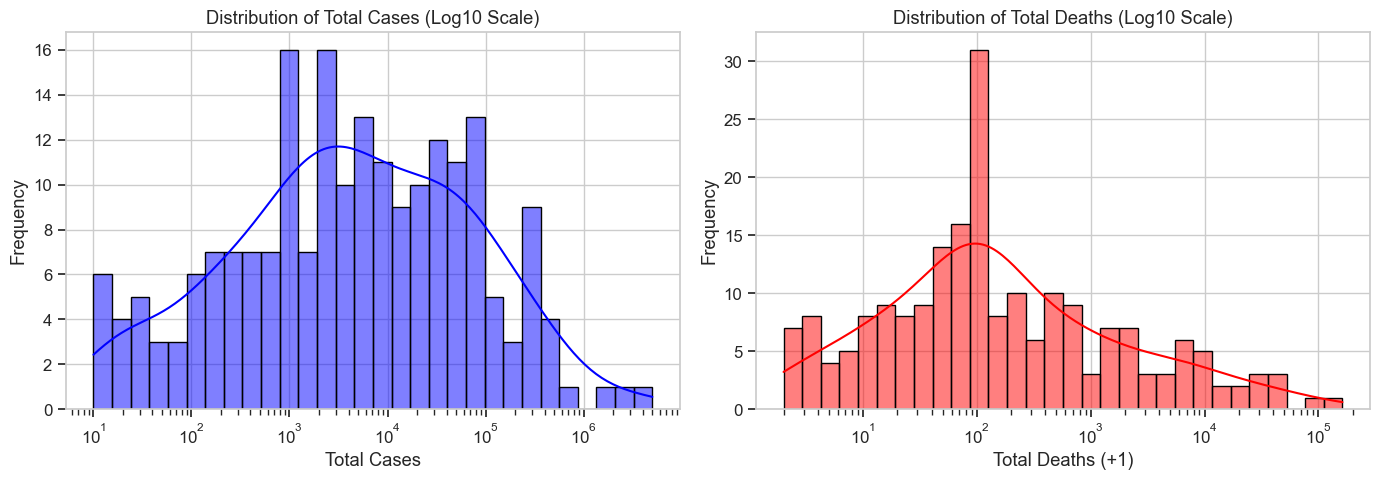

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of Total Cases (Log Scale)
sns.histplot(df['TotalCases'], bins=30, kde=True, log_scale=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of Total Cases (Log10 Scale)')
axes[0].set_xlabel('Total Cases')
axes[0].set_ylabel('Frequency')

# Distribution of Total Deaths (Log Scale, adding +1 to avoid log(0))
sns.histplot(df['TotalDeaths'] + 1, bins=30, kde=True, log_scale=True, ax=axes[1], color='red')
axes[1].set_title('Distribution of Total Deaths (Log10 Scale)')
axes[1].set_xlabel('Total Deaths (+1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Let's look at the distribution of our **calculated rates** (`CaseFatalityRate` and `RecoveryRate`), which are percentages and don't need a log scale.

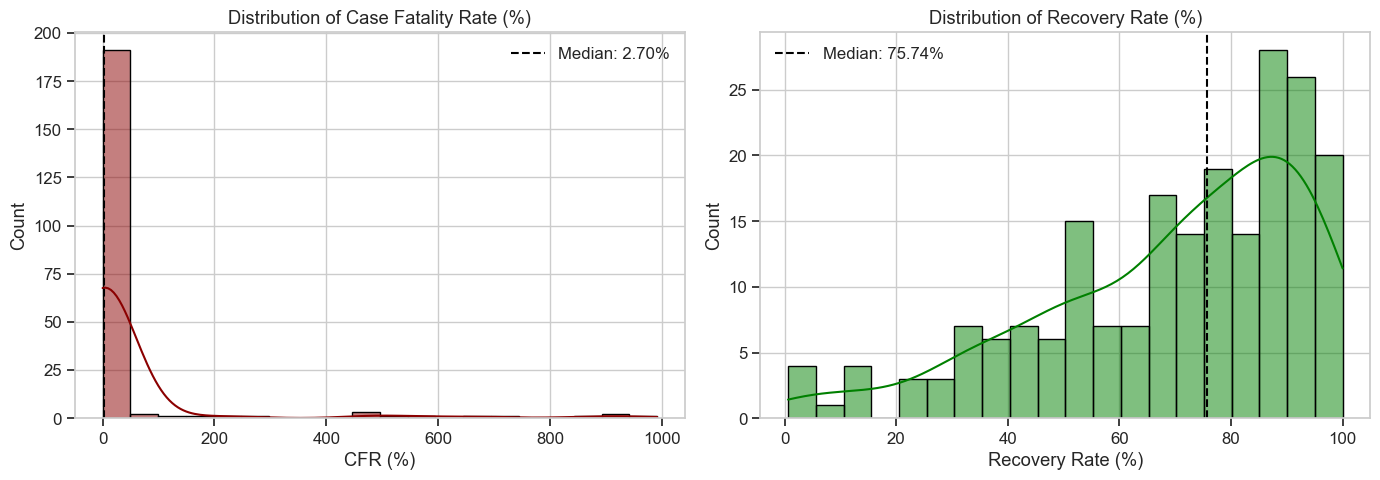

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Case Fatality Rate
sns.histplot(df['CaseFatalityRate'], bins=20, kde=True, ax=axes[0], color='darkred')
axes[0].set_title('Distribution of Case Fatality Rate (%)')
axes[0].set_xlabel('CFR (%)')
axes[0].axvline(df['CaseFatalityRate'].median(), color='black', linestyle='--', label=f'Median: {df["CaseFatalityRate"].median():.2f}%')
axes[0].legend()

# Recovery Rate
sns.histplot(df['RecoveryRate'], bins=20, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Recovery Rate (%)')
axes[1].set_xlabel('Recovery Rate (%)')
axes[1].axvline(df['RecoveryRate'].median(), color='black', linestyle='--', label=f'Median: {df["RecoveryRate"].median():.2f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 🔗 Step 5 — Correlation Analysis
How do different metrics relate to each other? For example, does testing more lead to a lower fatality rate?

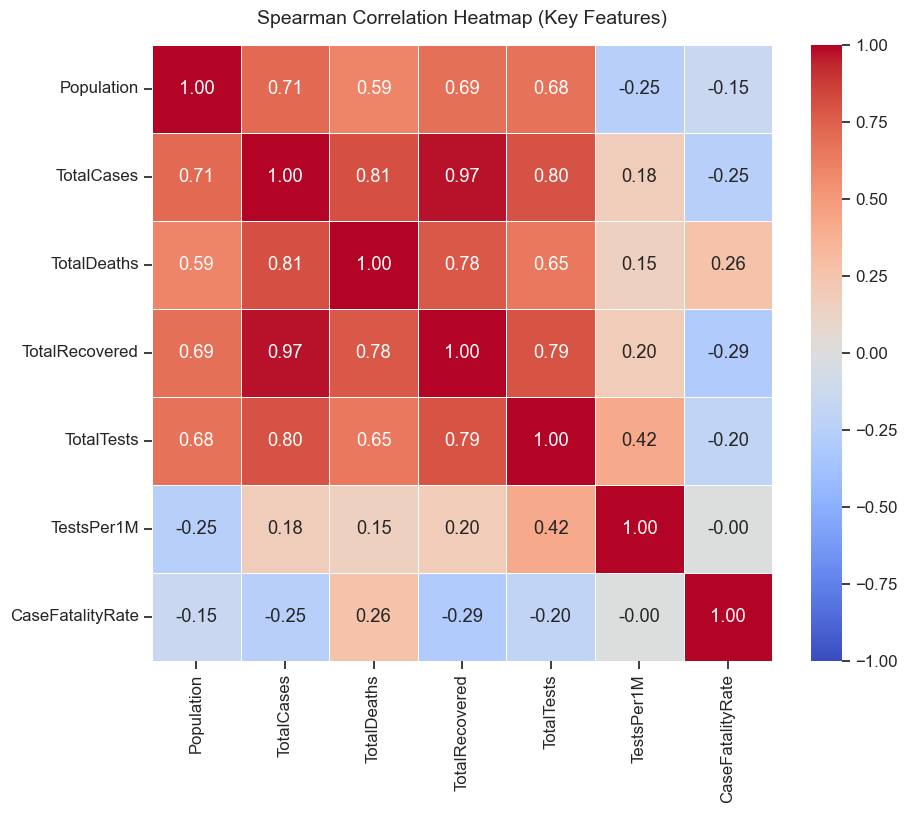

In [6]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Variables of interest
corr_cols = ['Population', 'TotalCases', 'TotalDeaths', 'TotalRecovered', 
             'TotalTests', 'TestsPer1M', 'CaseFatalityRate']

corr_matrix = numeric_df[corr_cols].corr(method='spearman') # Spearman is better for skewed data

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Spearman Correlation Heatmap (Key Features)', pad=15, size=14)
plt.show()

### 💡 Correlation Insights:
- **TotalCases & TotalDeaths** are highly positively correlated (close to 1), which is expected.
- **TotalTests & TotalCases** are also very highly correlated. More testing = more confirmed cases.
- **Case Fatality Rate** shows very weak correlation with most metrics.

---
## 🌍 Step 6 — Regional / Continental Aggregation
Let's see the macro-level impact by comparing Continents and WHO Regions.

In [7]:
# Group by Continent
continent_stats = df.groupby('Continent').agg({
    'Country': 'count',
    'TotalCases': 'sum',
    'TotalDeaths': 'sum',
    'TotalRecovered': 'sum',
}).rename(columns={'Country': 'Num_Countries'})

# Calculate Aggregated Rates
continent_stats['CFR (%)'] = (continent_stats['TotalDeaths'] / continent_stats['TotalCases'] * 100).round(2)
continent_stats['Recovery (%)'] = (continent_stats['TotalRecovered'] / continent_stats['TotalCases'] * 100).round(2)

continent_stats.sort_values('TotalCases', ascending=False)

,Num_Countries,TotalCases,TotalDeaths,TotalRecovered,CFR (%),Recovery (%)
Continent,,,,,,
North America,35,5919209,230688.0,3151678.0,3.90,53.24
Asia,48,4689794,101341.0,3508170.0,2.16,74.80
South America,14,4543273,155004.0,3116150.0,3.41,68.59
Europe,48,2982576,205589.0,1596022.0,6.89,53.51
Africa,57,1011867,22352.0,693620.0,2.21,68.55
Australia/Oceania,6,21735,519.0,12620.0,2.39,58.06


In [8]:
# Group by WHO Region
who_stats = df.groupby('WHORegion').agg({
    'Country': 'count',
    'TotalCases': 'sum',
    'TotalDeaths': 'sum',
}).rename(columns={'Country': 'Num_Countries'})

who_stats.sort_values('TotalCases', ascending=False)

,Num_Countries,TotalCases,TotalDeaths
WHORegion,,,
Americas,35,10452852,385113.0
Europe,55,3544086,215802.0
South-EastAsia,10,2426899,50862.0
EasternMediterranean,22,1605866,42376.0
Africa,47,852026,15776.0
WesternPacific,15,267114,4332.0
Unknown,24,19611,1232.0


---
## 🎉 EDA Complete!
We now thoroughly understand our data distribution, correlations, and general statistics. 

**Next up: Notebook 3 — Advanced Visualizations!**